   replicate  draw  top_rank_enrichment_score
0      rep_1     1                   3.589970
1      rep_1     2                   7.179940
2      rep_1     3                   9.573254
3      rep_1     4                   5.983284
4      rep_1     5                   7.179940
5      rep_1     6                   8.376597
6      rep_1     7                   7.179940
7      rep_1     8                   9.573254
8      rep_1     9                  13.761552
9      rep_1    10                   7.179940
10     rep_2     1                  58.123191
11     rep_2     2                  58.123191
12     rep_2     3                 154.152810
13     rep_2     4                  18.532032
14     rep_2     5                 134.778413
15     rep_2     6                  24.428587
16     rep_2     7                  54.753730
17     rep_2     8                 154.152810
18     rep_2     9                  58.123191
19     rep_2    10                 134.778413
20     rep_3     1                

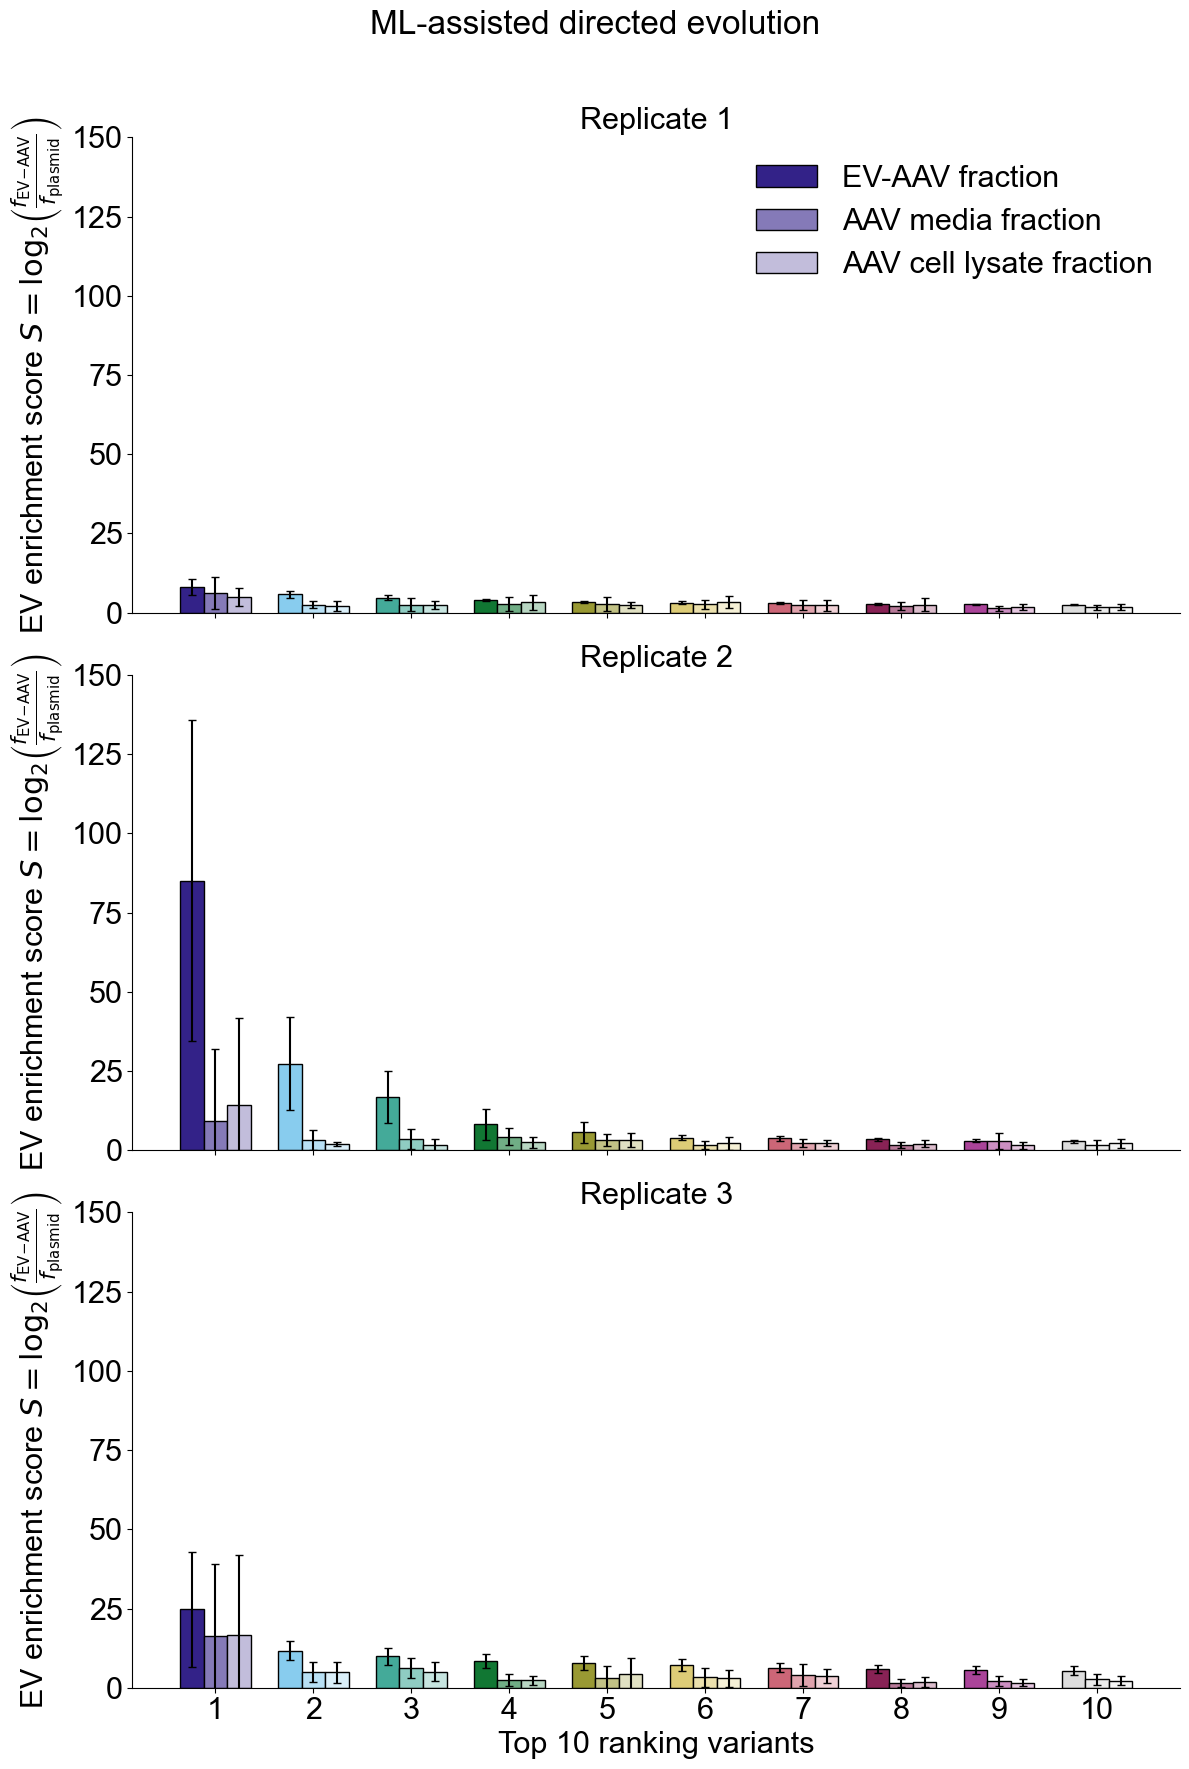

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.patches import Patch
from matplotlib.colors import to_rgb

# ───────────────────── USER SETTINGS ─────────────────────

xlsx_path = (
    "data/Excel/ml_assessment_library/EVAAV/"
    "merged_enrichment_scores_with_aa_column.xlsx"
)
xlsx_path_AAV = (
    "data/Excel/ml_assessment_library/AAV_media/"
    "merged_enrichment_scores_with_aa_column.xlsx"
)
xlsx_path_CL = (
    "data/Excel/ml_assessment_library/AAV_cell_lysate/"
    "merged_enrichment_scores_with_aa_column.xlsx"
)

rep_cols = [
    "enrichment_score_rep_1",
    "enrichment_score_rep_2",
    "enrichment_score_rep_3",
]

n_samples = 215
n_draws = 10
top_n = 10
random_state = 42

# Rank colors: rank 1 ... rank 10
tol_notes = [
    "#332288", "#88CCEE", "#44AA99", "#117733", "#999933",
    "#DDCC77", "#CC6677", "#882255", "#AA4499", "#DDDDDD"
]

# ───────────── LOAD & PREP DATA ─────────────
df = pd.read_excel(xlsx_path)
df_AAV = pd.read_excel(xlsx_path_AAV)
df_CL = pd.read_excel(xlsx_path_CL)

# Group by amino acid sequence and calculate mean for each replicate
avg_scores = df.groupby("amino_acid_sequence")[rep_cols].mean().reset_index()
avg_scores_AAV = df_AAV.groupby("amino_acid_sequence")[rep_cols].mean().reset_index()
avg_scores_CL = df_CL.groupby("amino_acid_sequence")[rep_cols].mean().reset_index()

# Rename columns so they do not collide after merge
avg_scores = avg_scores.rename(columns={
    "enrichment_score_rep_1": "EV_rep_1",
    "enrichment_score_rep_2": "EV_rep_2",
    "enrichment_score_rep_3": "EV_rep_3",
})

avg_scores_AAV = avg_scores_AAV.rename(columns={
    "enrichment_score_rep_1": "AAV_media_rep_1",
    "enrichment_score_rep_2": "AAV_media_rep_2",
    "enrichment_score_rep_3": "AAV_media_rep_3",
})

avg_scores_CL = avg_scores_CL.rename(columns={
    "enrichment_score_rep_1": "AAV_CL_rep_1",
    "enrichment_score_rep_2": "AAV_CL_rep_2",
    "enrichment_score_rep_3": "AAV_CL_rep_3",
})

# Merge all three datasets by sequence
merged = (
    avg_scores
    .merge(avg_scores_AAV, on="amino_acid_sequence", how="inner")
    .merge(avg_scores_CL, on="amino_acid_sequence", how="inner")
)

# ───────────── SAMPLING FUNCTION ─────────────
def sample_rank_positions(values, n_samples, rng):
    sample_n = min(n_samples, len(values))
    idx = rng.choice(len(values), size=sample_n, replace=False)
    idx.sort()
    return idx

# ───────────── BUILD RANKED DATA + SUBSAMPLING ─────────────
rng = np.random.RandomState(random_state)

replicates = [
    ("rep_1", "EV_rep_1", "AAV_media_rep_1", "AAV_CL_rep_1"),
    ("rep_2", "EV_rep_2", "AAV_media_rep_2", "AAV_CL_rep_2"),
    ("rep_3", "EV_rep_3", "AAV_media_rep_3", "AAV_CL_rep_3"),
]

all_results = []

for rep_name, ev_col, media_col, cl_col in replicates:
    df_rep = merged[[
        "amino_acid_sequence",
        ev_col,
        media_col,
        cl_col
    ]].copy()

    # Rank by EV score (descending)
    df_rep["rank"] = df_rep[ev_col].rank(method="first", ascending=False)
    df_rep.sort_values("rank", ascending=True, inplace=True)
    df_rep.reset_index(drop=True, inplace=True)

    # Draw the same subsampled rank positions for all three measurements
    idx_draws = []
    for _ in range(n_draws):
        idx = sample_rank_positions(df_rep[ev_col].to_numpy(), n_samples, rng)
        idx_draws.append(idx)

    rep_result = {
        "rep_name": rep_name,
        "df_ranked": df_rep,
        "EV": {},
        "AAV_media": {},
        "AAV_CL": {},
    }

    for label, col in [("EV", ev_col), ("AAV_media", media_col), ("AAV_CL", cl_col)]:
        values = df_rep[col].to_numpy()
        draws_matrix = np.array([values[idx] for idx in idx_draws])
        # Store individual enrichment score values for top-ranked variant
        top_rank_values = draws_matrix[:, 0]   # first column = top rank from each draw
        rep_result[label]["top_rank_values"] = top_rank_values
        # Store summary statistics
        rep_result[label]["mean"] = draws_matrix[:, :top_n].mean(axis=0)
        rep_result[label]["std"] = draws_matrix[:, :top_n].std(axis=0)

    all_results.append(rep_result)

# ───────────── SAVE TOP-RANK VALUES ─────────────

rows = []

for rep_result in all_results:
    rep_name = rep_result["rep_name"]

    for label in ["EV"]:
        vals = rep_result[label]["top_rank_values"]

        for draw_idx, val in enumerate(vals, start=1):
            rows.append({
                "replicate": rep_name,
                "draw": draw_idx,
                "top_rank_enrichment_score": val
            })

top_rank_df = pd.DataFrame(rows)

# Save to Excel
top_rank_df.to_excel(
    "data/Excel/ml_assessment_library/EVAAV/top_rank_enrichment_scores.xlsx",
    index=False
)

print(top_rank_df)

# ───────────── STYLE ─────────────
base_fs = 22
rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "axes.titlesize": base_fs,
    "axes.labelsize": base_fs,
    "xtick.labelsize": base_fs,
    "ytick.labelsize": base_fs,
    "legend.fontsize": base_fs,
})

# mix with white
def lighten(col, frac):
    col = np.array(to_rgb(col))
    return tuple(col + (1 - col) * frac)

# ───────────────────── PLOT ─────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)

x = np.arange(1, top_n + 1)
bar_width = 0.24
offsets = [-bar_width, 0.0, bar_width]

for i, (ax, rep_result) in enumerate(zip(axes, all_results), start=1):

    # Base colors per rank
    base_colors = tol_notes[:top_n]

    # Lightened variants
    media_colors = [lighten(c, 0.4) for c in base_colors]
    cl_colors = [lighten(c, 0.7) for c in base_colors]

    # Extract data
    ev_mean = rep_result["EV"]["mean"]
    ev_std = rep_result["EV"]["std"]

    media_mean = rep_result["AAV_media"]["mean"]
    media_std = rep_result["AAV_media"]["std"]

    cl_mean = rep_result["AAV_CL"]["mean"]
    cl_std = rep_result["AAV_CL"]["std"]

    # Plot bars
    ax.bar(
        x + offsets[0],
        ev_mean,
        yerr=ev_std,
        capsize=3,
        width=bar_width,
        color=base_colors,
        edgecolor="black",
        label="EV-AAV fraction"
    )

    ax.bar(
        x + offsets[1],
        media_mean,
        yerr=media_std,
        capsize=3,
        width=bar_width,
        color=media_colors,
        edgecolor="black",
        label="AAV media fraction"
    )

    ax.bar(
        x + offsets[2],
        cl_mean,
        yerr=cl_std,
        capsize=3,
        width=bar_width,
        color=cl_colors,
        edgecolor="black",
        label="AAV cell lysate fraction"
    )

    ax.set_title(f"Replicate {i}")
    ax.set_ylabel(r"EV enrichment score $S = \log_2\left(\frac{f_{\mathrm{EV\!-\!AAV}}}{f_{\mathrm{plasmid}}}\right)$", fontsize=base_fs)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, 150)

axes[-1].set_xlabel("Top 10 ranking variants", fontsize=base_fs)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels([str(i) for i in range(1, top_n + 1)])

# Legend (only once)
axes[0].legend(frameon=False, loc="upper right")

fig.suptitle("ML-assisted directed evolution", fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib import colors as mcolors

# ───────────────────── USER SETTINGS ─────────────────────
xlsx_path = (
    "data/Excel/directed_evolution_assessment_library/merged_enrichment_scores_with_aa_column.xlsx"
)

rep_cols = [
    "enrichment_score_rep_1",
    "enrichment_score_rep_2",
    "enrichment_score_rep_3",
]

# Paul Tol "Notes" palette
tol_notes = [
    "#332288", "#88CCEE", "#44AA99", "#117733", "#999933",
    "#DDCC77", "#CC6677", "#882255", "#AA4499", "#DDDDDD"
]

# ───────────── LOAD & PREP DATA ─────────────
df = pd.read_excel(xlsx_path)

# Group by amino acid sequence and calculate mean for each replicate
avg_scores = df.groupby("amino_acid_sequence")[rep_cols].mean().reset_index()

# Create replicate-specific dataframes including sequence
df_rep1 = avg_scores[["amino_acid_sequence", "enrichment_score_rep_1"]].copy()
df_rep2 = avg_scores[["amino_acid_sequence", "enrichment_score_rep_2"]].copy()
df_rep3 = avg_scores[["amino_acid_sequence", "enrichment_score_rep_3"]].copy()

# Rank each replicate independently
df_rep1["rank"] = df_rep1["enrichment_score_rep_1"].rank(method="first")
df_rep1.sort_values("rank", ascending=False, inplace=True)

df_rep2["rank"] = df_rep2["enrichment_score_rep_2"].rank(method="first")
df_rep2.sort_values("rank", ascending=False, inplace=True)

df_rep3["rank"] = df_rep3["enrichment_score_rep_3"].rank(method="first")
df_rep3.sort_values("rank", ascending=False, inplace=True)

# Merge by rank so all three replicates are aligned
df_combined = (
    df_rep1.rename(columns={"amino_acid_sequence": "sequence_rep_1"})
    .merge(df_rep2.rename(columns={"amino_acid_sequence": "sequence_rep_2"}), on="rank", how="inner")
    .merge(df_rep3.rename(columns={"amino_acid_sequence": "sequence_rep_3"}), on="rank", how="inner")
)

# Calculate arithmetic mean and standard error across replicates
df_combined["arithmetic_mean_enrichment"] = df_combined[rep_cols].mean(axis=1)
df_combined["std_error"] = df_combined[rep_cols].sem(axis=1)

display(df_combined)

top10_df = df_combined.head(10).reset_index(drop=True)

# ───────────── SAVE TOP-RANK ENRICHMENT SCORES ─────────────

top_rank_rows = []

replicate_info = [
    ("enrichment_score_rep_1", "rep_1"),
    ("enrichment_score_rep_2", "rep_2"),
    ("enrichment_score_rep_3", "rep_3"),
]

# Extract the top-ranked enrichment score for each replicate
for col, rep_name in replicate_info:

    top_value = top10_df.loc[0, col]  # first row = rank 1

    top_rank_rows.append({
        "replicate": rep_name,
        "top_rank_enrichment_score": top_value
    })

# Convert to dataframe
top_rank_df = pd.DataFrame(top_rank_rows)

# Save to Excel
top_rank_df.to_excel(
    "data/Excel/directed_evolution_assessment_library/top_rank_enrichment_scores.xlsx",
    index=False
)

print(top_rank_df)

# ─────────────── STYLE CONSTANTS ───────────────
base_fs = 22
rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "axes.titlesize": base_fs,
    "axes.labelsize": base_fs,
    "xtick.labelsize": base_fs,
    "ytick.labelsize": base_fs,
    "legend.fontsize": base_fs,
})

# ───────────────────── PLOT ─────────────────────
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 18),
    sharex=True
)

x = np.arange(len(top10_df))
width = 0.25

replicate_info = [
    ("enrichment_score_rep_1", "Replicate 1"),
    ("enrichment_score_rep_2", "Replicate 2"),
    ("enrichment_score_rep_3", "Replicate 3"),
]

for ax, (col, title) in zip(axes, replicate_info):
    for xi in x:
        col_ev = mcolors.to_rgb(tol_notes[xi % len(tol_notes)])
        ax.bar(
            xi,
            top10_df.loc[xi, col],
            width,
            color=col_ev,
            edgecolor="black",
            linewidth=1.2,
            label="EV-AAV fraction" if xi == 0 else None  # only label once
        )

    ax.set_title(title)
    ax.set_ylabel(r"EV enrichment score $S = \log_2\left(\frac{f_{\mathrm{EV\!-\!AAV}}}{f_{\mathrm{plasmid}}}\right)$", fontsize=base_fs)
    ax.spines[["top", "right"]].set_visible(False)

    minor_ticks = [25, 50, 75, 100, 125, 150]
    ax.set_yticks(minor_ticks, minor=True)
    ax.tick_params(axis="y", which="minor", length=5)
    ax.set_ylim(0, 150)

axes[-1].set_xlabel("Top 10 ranking variants", fontsize=base_fs)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels([f"{i+1}" for i in x])

# Legend (only once)
axes[0].legend(frameon=False, loc="upper right")

fig.suptitle("Standard directed evolution", fontsize=24, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

# ───────────────────── LOAD DATA ─────────────────────

ml_path = "data/Excel/ml_assessment_library/EVAAV/top_rank_enrichment_scores.xlsx"

standard_path = "data/Excel/directed_evolution_assessment_library/top_rank_enrichment_scores.xlsx"

df_ml = pd.read_excel(ml_path)
df_standard = pd.read_excel(standard_path)

# ───────────────────── EXTRACT VALUES ─────────────────────

# ML-assisted directed evolution
# (10 subsamples per replicate)
ml_scores = df_ml["top_rank_enrichment_score"].dropna().to_numpy()

# Standard directed evolution
# (1 value per replicate)
standard_scores = (
    df_standard["top_rank_enrichment_score"]
    .dropna()
    .to_numpy()
)

# ───────────────────── MANN-WHITNEY U TEST ─────────────────────

u_statistic, p_value = mannwhitneyu(
    ml_scores,
    standard_scores,
    alternative="greater"
)

# ───────────────────── OUTPUT ─────────────────────

print("Mann–Whitney U test")
print("-------------------")
print(f"ML-assisted group size: {len(ml_scores)}")
print(f"Standard DE group size: {len(standard_scores)}")
print(f"U statistic: {u_statistic:.4f}")
print(f"P-value: {p_value:.6e}")

# Interpretation
alpha = 0.01

if p_value <= alpha:
    print("\nResult: The two groups are statistically significantly different.")
else:
    print("\nResult: No statistically significant difference detected.")